# PCSE Yield Prediction — LightGBM Regresyon

**Hedef:** `twso_final` (kg/ha eşdeğeri tane verimi)  
**Veri:** `ml_dataset_gunluk.parquet` (pipeline_01 çıktısı)  
**İçerik:**
1. Veri yükle & keşif
2. DVS < 1.0 filtresi + Feature seçimi
3. GroupKFold validasyon
4. Hyperparameter tuning (Optuna)
5. Final model eğitimi
6. Feature importance
7. SHAP analizi
8. Hata analizi
9. Crop bazlı breakdown
10. Model kaydetme

In [1]:
# !pip install lightgbm optuna shap matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import shap
import joblib
import warnings
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

BASE_DIR     = Path('..').resolve()
DATA_DIR     = BASE_DIR / 'data'
MODEL_DIR    = BASE_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)

COMBO        = ['district_name', 'crop_name', 'variety_name']
TARGET       = 'twso_final'
RANDOM_STATE = 42

print('Kütüphaneler yüklendi.')
print(f'LightGBM : {lgb.__version__}')
print(f'Optuna   : {optuna.__version__}')

Kütüphaneler yüklendi.
LightGBM : 4.6.0
Optuna   : 4.8.0


---
## 1. Veri Yükle & Keşif

In [3]:
df_raw = pd.read_parquet(DATA_DIR / 'ml_dataset_gunluk.parquet')
print(f'Ham veri  — Satır: {len(df_raw):,}  |  Sütun: {df_raw.shape[1]}')
print(f'Kombinasyon: {df_raw.groupby(COMBO).ngroups}')
print(f'Tarih: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
df_raw.head(3)

Ham veri  — Satır: 88,011  |  Sütun: 49
Kombinasyon: 295
Tarih: 2023-01-01 → 2024-06-10


,date,district_name,crop_name,variety_name,AIR_TEMP_mean,AIR_TEMP_min,AIR_TEMP_max,AIR_HUMIDITY_mean,AIR_HUMIDITY_min,AIR_HUMIDITY_max,...,growth_stage,twso_final,latitude,longitude,soil_type,crop_name_enc,variety_name_enc,district_name_enc,soil_type_enc,growth_stage_enc
0,2023-01-01,"Adana, Karataş",barley,Spring_barley_301,13.033333,7.85,17.5,49.395826,38.62529,62.601112,...,pre_sowing,2187.875065,36.575,35.375,Very Fine Heavy Clay,0,15,0,11,2
1,2023-01-01,"Adana, Karataş",cassava,Cassava_VanHeemst_1988,13.033333,7.85,17.5,49.395826,38.62529,62.601112,...,pre_sowing,14.323044,36.575,35.375,Very Fine Heavy Clay,1,0,0,11,2
2,2023-01-01,"Adana, Karataş",chickpea,Chickpea_VanHeemst_1988,13.033333,7.85,17.5,49.395826,38.62529,62.601112,...,pre_sowing,105.899010,36.575,35.375,Very Fine Heavy Clay,2,1,0,11,2


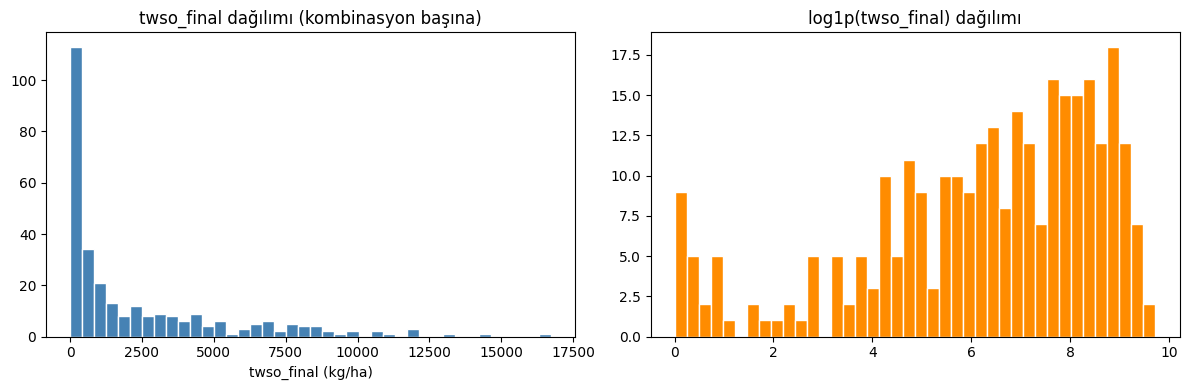

count      295.0
mean      2325.6
std       3095.1
min          0.0
25%        127.2
50%        850.6
75%       3381.0
max      16724.7
Name: twso_final, dtype: float64


In [4]:
combo_verim = df_raw.groupby(COMBO)[TARGET].first()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(combo_verim, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('twso_final dağılımı (kombinasyon başına)')
axes[0].set_xlabel('twso_final (kg/ha)')
axes[1].hist(np.log1p(combo_verim), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(twso_final) dağılımı')
plt.tight_layout()
plt.show()
print(combo_verim.describe().round(1))

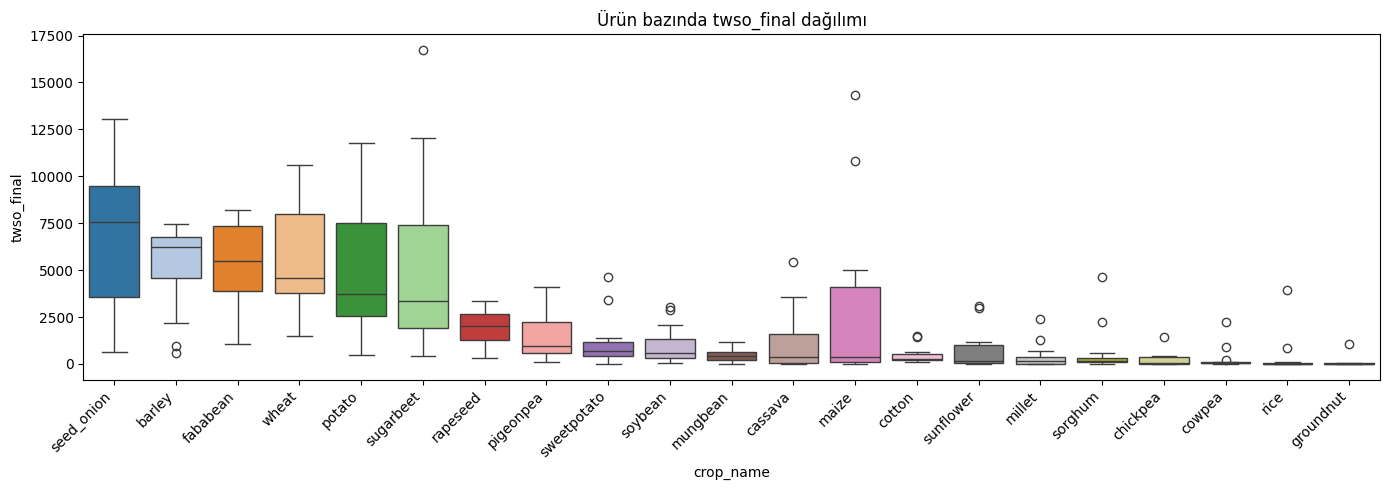

In [5]:
plt.figure(figsize=(14, 5))
order = combo_verim.reset_index().groupby('crop_name')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=combo_verim.reset_index(), x='crop_name', y=TARGET, order=order, palette='tab20')
plt.xticks(rotation=45, ha='right')
plt.title('Ürün bazında twso_final dağılımı')
plt.tight_layout()
plt.show()

---
## 2. DVS < 1.0 Filtresi + Feature Seçimi

**Neden DVS < 1.0?**  
DVS ≥ 1.0 döneminde biyokütle değişkenleri hasat verimiyle neredeyse doğrusal ilişkiye girer → sızıntı.  
Model vejetatif dönemde (erken sezonda) tahmin yapabilmeli — bu daha gerçekçi ve pratik.

**Çıkarılan sızdırıcı sütunlar:**  
`TWSO`, `TAGP`, `TWLV`, `TWST`, `TWRT` — hasat sonuna yaklaştıkça target ile yüksek korelasyon.

In [6]:
df = df_raw[df_raw['DVS'] < 1.0].copy().reset_index(drop=True)

print(f'DVS < 1.0 sonrası — Satır: {len(df):,}  ({len(df)/len(df_raw)*100:.1f}%)')
print(f'Kombinasyon: {df.groupby(COMBO).ngroups}')
print(f'DVS aralığı: {df["DVS"].min():.3f} → {df["DVS"].max():.3f}')

DVS < 1.0 sonrası — Satır: 24,080  (27.4%)
Kombinasyon: 295
DVS aralığı: -0.100 → 1.000


In [7]:
LEAKY_COLS = ['TWSO', 'TAGP', 'TWLV', 'TWST', 'TWRT']

DROP_COLS = [
    'date', 'district_name', 'crop_name', 'variety_name',
    'soil_type', 'growth_stage',
    'tbase',
    TARGET,
    *LEAKY_COLS
]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
print(f'Feature sayısı: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Feature sayısı: 36
['AIR_TEMP_mean', 'AIR_TEMP_min', 'AIR_TEMP_max', 'AIR_HUMIDITY_mean', 'AIR_HUMIDITY_min', 'AIR_HUMIDITY_max', 'PRECIP_sum', 'SOIL_TEMP_0_7_mean', 'SOIL_MOISTURE_0_7_mean', 'DVS', 'LAI', 'TRA', 'RD', 'SM', 'WWLOW', 'RFTRA', 'GDD_daily', 'GDD_cumsum', 'PRECIP_cumsum', 'AIR_TEMP_mean_roll7', 'AIR_TEMP_mean_roll30', 'AIR_HUMIDITY_mean_roll7', 'AIR_HUMIDITY_mean_roll30', 'SOIL_MOISTURE_0_7_mean_roll7', 'SOIL_MOISTURE_0_7_mean_roll30', 'TEMP_range', 'day_of_year', 'month', 'week', 'latitude', 'longitude', 'crop_name_enc', 'variety_name_enc', 'district_name_enc', 'soil_type_enc', 'growth_stage_enc']


In [8]:
X      = df[FEATURE_COLS].copy()
y      = df[TARGET].copy()
groups = df[COMBO].apply(lambda r: '||'.join(r), axis=1)

missing = X.isna().sum()
if missing.any():
    print('Eksik değer olan sütunlar:')
    print(missing[missing > 0])
    X = X.fillna(X.median())
    print('Medyan ile dolduruldu.')
else:
    print('Eksik değer yok ✓')

print(f'\nX shape : {X.shape}')
print(f'y stats : mean={y.mean():.1f}  std={y.std():.1f}  min={y.min():.1f}  max={y.max():.1f}')

Eksik değer yok ✓

X shape : (24080, 36)
y stats : mean=2512.8  std=3006.7  min=0.0  max=16724.7


---
## 3. GroupKFold Validasyon

Her fold'da farklı `district × crop × variety` kombinasyonları test setine girer.  
Model hiç görmediği kombinasyonlarda genelleme gücü ölçülür.

In [9]:
N_SPLITS = 5
gkf      = GroupKFold(n_splits=N_SPLITS)
FINAL_CV = list(gkf.split(X, y, groups))

# Son fold → final test seti
last_train_idx, last_test_idx = FINAL_CV[-1]
X_train = X.iloc[last_train_idx]
X_test  = X.iloc[last_test_idx]
y_train = y.iloc[last_train_idx]
y_test  = y.iloc[last_test_idx]

print(f'GroupKFold ({N_SPLITS} fold):')
for i, (tr, val) in enumerate(FINAL_CV):
    print(f'  Fold {i+1}: train={len(tr):>6,} satır ({groups.iloc[tr].nunique()} kombo)  |  '
          f'val={len(val):>5,} satır ({groups.iloc[val].nunique()} kombo)')
print(f'\nFinal test seti (fold {N_SPLITS}): {len(X_test):,} satır')

GroupKFold (5 fold):
  Fold 1: train=19,264 satır (236 kombo)  |  val=4,816 satır (59 kombo)
  Fold 2: train=19,264 satır (236 kombo)  |  val=4,816 satır (59 kombo)
  Fold 3: train=19,265 satır (236 kombo)  |  val=4,815 satır (59 kombo)
  Fold 4: train=19,263 satır (236 kombo)  |  val=4,817 satır (59 kombo)
  Fold 5: train=19,264 satır (236 kombo)  |  val=4,816 satır (59 kombo)

Final test seti (fold 5): 4,816 satır


In [10]:
# Baseline CV (tuning öncesi)
BASE_PARAMS = {
    'objective': 'regression', 'metric': 'rmse',
    'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63,
    'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1,
}

rmse_cv, r2_cv = [], []
for tr, val in FINAL_CV:
    m = lgb.LGBMRegressor(**BASE_PARAMS)
    m.fit(X.iloc[tr], y.iloc[tr],
          eval_set=[(X.iloc[val], y.iloc[val])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    p = m.predict(X.iloc[val])
    rmse_cv.append(mean_squared_error(y.iloc[val], p) ** 0.5)
    r2_cv.append(r2_score(y.iloc[val], p))

print(f'Baseline GroupKFold CV (DVS<1, sızıntı yok):')
print(f'  RMSE : {np.mean(rmse_cv):.1f} ± {np.std(rmse_cv):.1f}')
print(f'  R²   : {np.mean(r2_cv):.4f}')

Baseline GroupKFold CV (DVS<1, sızıntı yok):
  RMSE : 1664.7 ± 247.9
  R²   : 0.6804


---
## 4. Hyperparameter Tuning (Optuna)

In [11]:
def objective(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse',
        'verbosity': -1, 'n_jobs': -1, 'random_state': RANDOM_STATE,
        'n_estimators':      1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
    }
    rmse_list = []
    for tr, val in FINAL_CV:
        m = lgb.LGBMRegressor(**params)
        m.fit(X.iloc[tr], y.iloc[tr],
              eval_set=[(X.iloc[val], y.iloc[val])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        p = m.predict(X.iloc[val])
        rmse_list.append(mean_squared_error(y.iloc[val], p) ** 0.5)
    return np.mean(rmse_list)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\nBaseline CV RMSE : {np.mean(rmse_cv):.2f}')
print(f'Optuna CV RMSE   : {study.best_value:.2f}')
print(f'İyileşme         : {np.mean(rmse_cv) - study.best_value:.2f}')
print('\nEn iyi params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/80 [00:00<?, ?it/s]


Baseline CV RMSE : 1664.70
Optuna CV RMSE   : 1451.61
İyileşme         : 213.09

En iyi params:
  learning_rate: 0.03077330894533339
  num_leaves: 192
  max_depth: 6
  min_child_samples: 34
  subsample: 0.8792593114879927
  colsample_bytree: 0.6452039710701697
  reg_alpha: 5.5556792273561445e-06
  reg_lambda: 3.402126601660682e-05
  min_split_gain: 0.09942694455983636


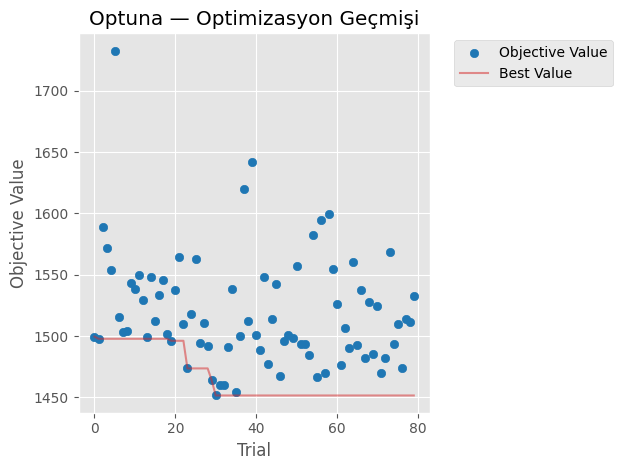

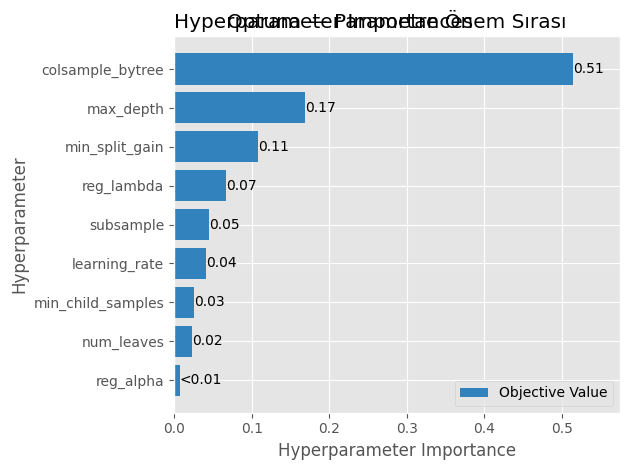

In [12]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna — Optimizasyon Geçmişi')
plt.tight_layout()
plt.show()

fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title('Optuna — Parametre Önem Sırası')
plt.tight_layout()
plt.show()

---
## 5. Final Model Eğitimi

In [13]:
BEST_PARAMS = {
    'objective': 'regression', 'metric': 'rmse',
    'n_estimators': 2000, 'n_jobs': -1, 'random_state': RANDOM_STATE,
    **study.best_params
}

final_model = lgb.LGBMRegressor(**BEST_PARAMS)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(100, verbose=True), lgb.log_evaluation(100)]
)

y_pred = final_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100

print('\n── Final Model Test Metrikleri (GroupKFold, DVS<1) ──')
print(f'RMSE : {rmse:>8.2f}')
print(f'MAE  : {mae:>8.2f}')
print(f'R²   : {r2:>8.4f}')
print(f'MAPE : {mape:>7.2f}%')

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 1274.69
[200]	valid_0's rmse: 1211.13
[300]	valid_0's rmse: 1202.25
[400]	valid_0's rmse: 1193.99
[500]	valid_0's rmse: 1190.1
[600]	valid_0's rmse: 1188.47
[700]	valid_0's rmse: 1187.58
[800]	valid_0's rmse: 1186.18
[900]	valid_0's rmse: 1184.83
[1000]	valid_0's rmse: 1183.69
[1100]	valid_0's rmse: 1181.94
[1200]	valid_0's rmse: 1180.87
[1300]	valid_0's rmse: 1180.48
[1400]	valid_0's rmse: 1179.97
[1500]	valid_0's rmse: 1179.64
[1600]	valid_0's rmse: 1179.56
Early stopping, best iteration is:
[1535]	valid_0's rmse: 1179.39

── Final Model Test Metrikleri (GroupKFold, DVS<1) ──
RMSE :  1179.39
MAE  :   792.21
R²   :   0.8207
MAPE : 28976.35%


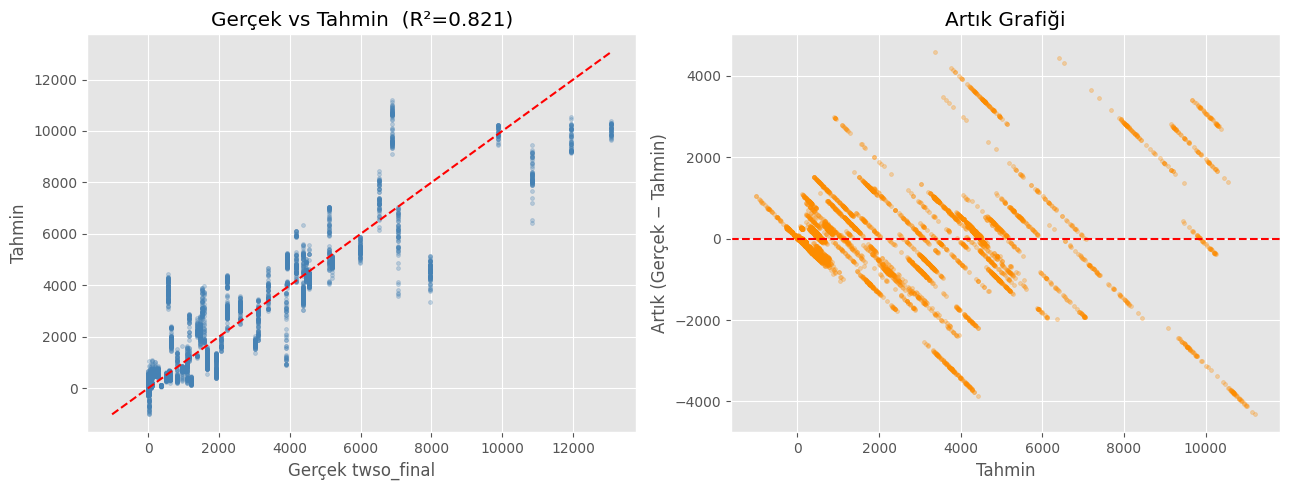

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Gerçek twso_final')
axes[0].set_ylabel('Tahmin')
axes[0].set_title(f'Gerçek vs Tahmin  (R²={r2:.3f})')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='darkorange')
axes[1].axhline(0, color='r', lw=1.5, ls='--')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Artık (Gerçek − Tahmin)')
axes[1].set_title('Artık Grafiği')

plt.tight_layout()
plt.show()

---
## 6. Feature Importance

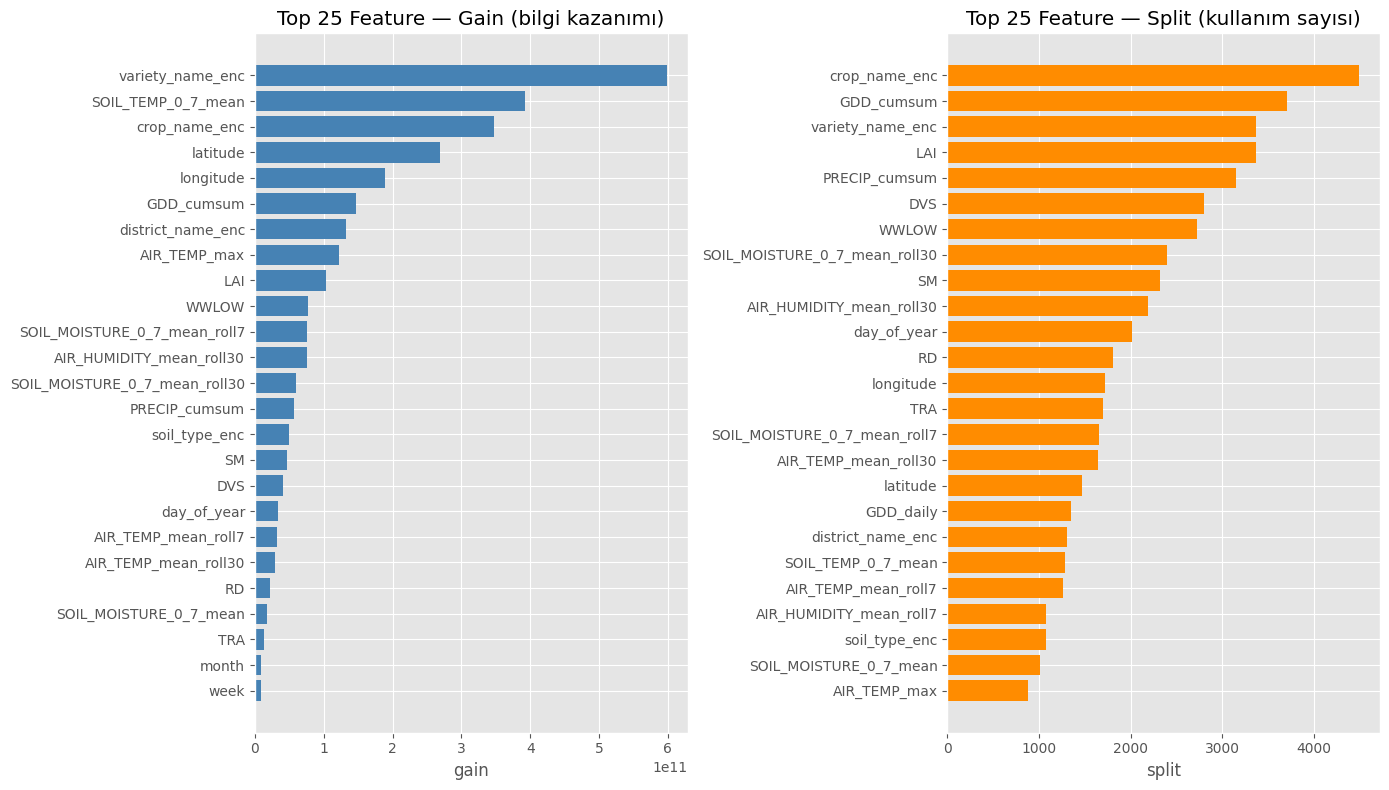

Top 15 feature (gain):
                      feature         gain  split
             variety_name_enc 5.985803e+11   3364
           SOIL_TEMP_0_7_mean 3.924444e+11   1279
                crop_name_enc 3.478394e+11   4498
                     latitude 2.683371e+11   1472
                    longitude 1.896228e+11   1719
                   GDD_cumsum 1.476129e+11   3706
            district_name_enc 1.318457e+11   1310
                 AIR_TEMP_max 1.222849e+11    880
                          LAI 1.034313e+11   3364
                        WWLOW 7.654230e+10   2724
 SOIL_MOISTURE_0_7_mean_roll7 7.638445e+10   1651
     AIR_HUMIDITY_mean_roll30 7.620862e+10   2189
SOIL_MOISTURE_0_7_mean_roll30 5.918014e+10   2401
                PRECIP_cumsum 5.718041e+10   3151
                soil_type_enc 4.954353e+10   1074


In [15]:
imp_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain':    final_model.booster_.feature_importance(importance_type='gain'),
    'split':   final_model.booster_.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

top_n = 25
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, col, color, title in [
    (axes[0], 'gain',  'steelblue', 'Gain (bilgi kazanımı)'),
    (axes[1], 'split', 'darkorange', 'Split (kullanım sayısı)'),
]:
    sub = imp_df.nlargest(top_n, col)
    ax.barh(sub['feature'][::-1], sub[col][::-1], color=color)
    ax.set_title(f'Top {top_n} Feature — {title}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

print('Top 15 feature (gain):')
print(imp_df.head(15)[['feature','gain','split']].to_string(index=False))

---
## 7. SHAP Analizi

In [16]:
sample_idx  = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
X_shap      = X_test.iloc[sample_idx]
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
print('SHAP değerleri hesaplandı.')

SHAP değerleri hesaplandı.


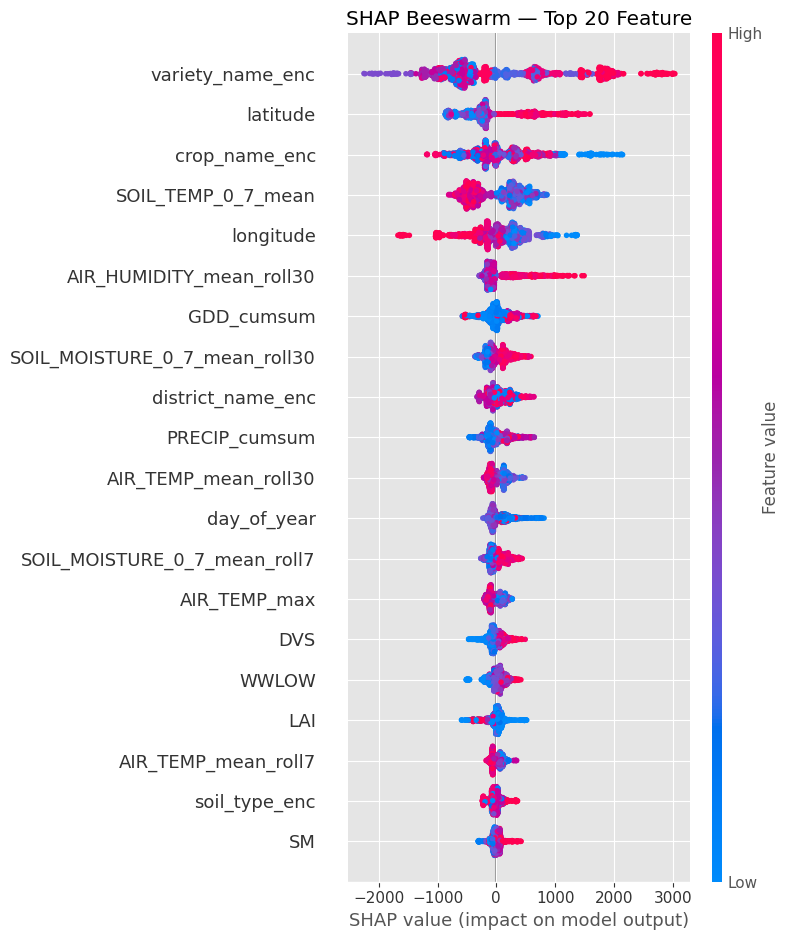

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP Beeswarm — Top 20 Feature')
plt.tight_layout()
plt.show()

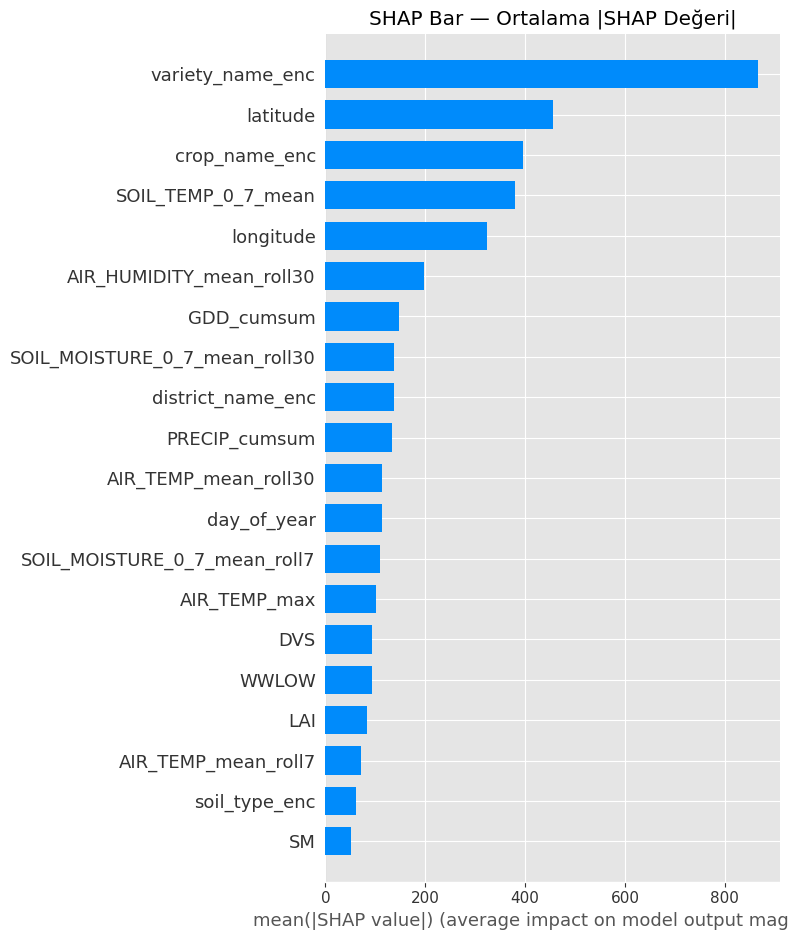

In [18]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Bar — Ortalama |SHAP Değeri|')
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

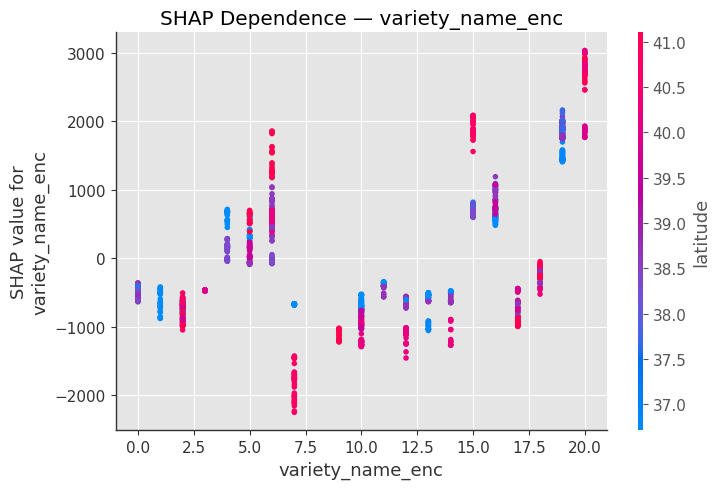

<Figure size 800x400 with 0 Axes>

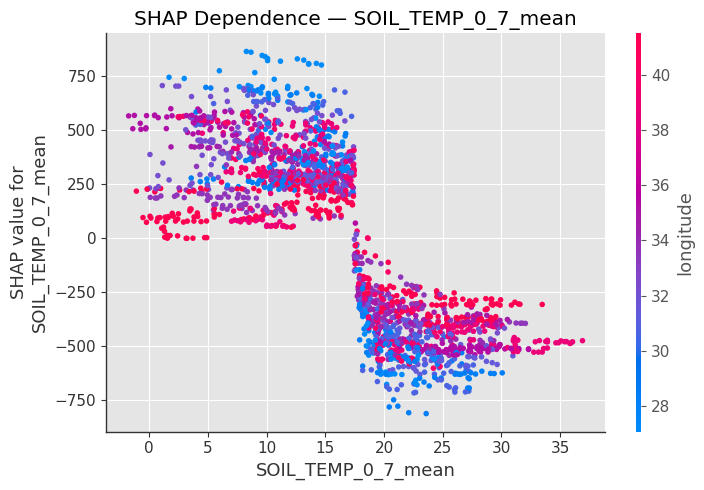

In [19]:
top2 = imp_df['feature'].head(2).tolist()
for feat in top2:
    plt.figure(figsize=(8, 4))
    shap.dependence_plot(feat, shap_values, X_shap, show=False)
    plt.title(f'SHAP Dependence — {feat}')
    plt.tight_layout()
    plt.show()

---
## 8. Hata Analizi

In [20]:
test_df = df.iloc[last_test_idx].copy()
test_df['y_pred']    = y_pred
test_df['residual']  = y_test.values - y_pred
test_df['abs_error'] = np.abs(test_df['residual'])
test_df['rel_error'] = test_df['abs_error'] / (test_df[TARGET] + 1e-6) * 100

print('── Hata istatistikleri ──')
print(test_df[['abs_error','rel_error']].describe().round(2))

── Hata istatistikleri ──
       abs_error   rel_error
count    4816.00     4816.00
mean      792.21    28976.35
std       873.79   191240.29
min         0.14        0.00
25%       230.67       16.46
50%       482.70       34.52
75%       984.13      121.01
max      4579.90  2136667.51


In [21]:
worst = (
    test_df.groupby(COMBO)[['abs_error','rel_error', TARGET, 'y_pred']]
    .mean().sort_values('abs_error', ascending=False).head(20).round(1)
)
print('En yüksek hatalı kombinasyonlar:')
worst

En yüksek hatalı kombinasyonlar:


abs_error  \
district_name                 crop_name   variety_name                            
Şanlıurfa, Akçakale           fababean    Faba_bean_801                  3423.8   
Trabzon, Köprübaşı (Ağaçbaşı) barley      Spring_barley_301              3276.0   
                              cotton      Cotton_VanHeemst_1988          3218.6   
Sakarya, Karasu               seed_onion  onion_agriadapt                3025.3   
                              maize       Fodder_maize_nl                2554.7   
Trabzon, Köprübaşı (Ağaçbaşı) seed_onion  onion_agriadapt                2241.3   
Şanlıurfa, Akçakale           potato      Festien                        1697.6   
İzmir, Menemen                maize       Fodder_maize_nl                1523.0   
Nevşehir, Avanos              potato      Festien                        1259.3   
Sakarya, Karasu               mungbean    Mungbean_VanHeemst_1988        1250.2   
İzmir, Menemen                sugarbeet   Sugarbeet_601                  1154.4   
Iğdır, Aralık                 seed_onion  onion_agriadapt                1131.8   
Ankara, Polatlı               rapeseed    Oilseed_rape_1001              1070.3   
Muş, Merkez                   cassava     Cassava_VanHeemst_1988         1052.5   
Ankara, Polatlı               potato      Festien                         938.5   
Edirne, Uzunköprü             potato      Festien                         916.0   
Muş, Merkez                   sweetpotato Sweetpotato_VanHeemst_1988      914.3   
Adana, Karataş                sugarbeet   Sugarbeet_601                   913.3   
Antalya, Manavgat             wheat       Winter_wheat_101                912.5   
Şanlıurfa, Akçakale           sugarbeet   Sugarbeet_601                   851.0   

                                                                      rel_error  \
district_name                 crop_name   variety_name                            
Şanlıurfa, Akçakale           fababean    Faba_bean_801                    43.1   
Trabzon, Köprübaşı (Ağaçbaşı) barley      Spring_barley_301                47.5   
                              cotton      Cotton_VanHeemst_1988           564.7   
Sakarya, Karasu               seed_onion  onion_agriadapt                  23.1   
                              maize       Fodder_maize_nl                  23.6   
Trabzon, Köprübaşı (Ağaçbaşı) seed_onion  onion_agriadapt                  18.8   
Şanlıurfa, Akçakale           potato      Festien                         112.0   
İzmir, Menemen                maize       Fodder_maize_nl                  39.2   
Nevşehir, Avanos              potato      Festien                          41.7   
Sakarya, Karasu               mungbean    Mungbean_VanHeemst_1988         191.9   
İzmir, Menemen                sugarbeet   Sugarbeet_601                    16.4   
Iğdır, Aralık                 seed_onion  onion_agriadapt                 174.2   
Ankara, Polatlı               rapeseed    Oilseed_rape_1001                48.2   
Muş, Merkez                   cassava     Cassava_VanHeemst_1988           55.0   
Ankara, Polatlı               potato      Festien                          18.3   
Edirne, Uzunköprü             potato      Festien                          14.1   
Muş, Merkez                   sweetpotato Sweetpotato_VanHeemst_1988       76.3   
Adana, Karataş                sugarbeet   Sugarbeet_601                    57.4   
Antalya, Manavgat             wheat       Winter_wheat_101                 23.3   
Şanlıurfa, Akçakale           sugarbeet   Sugarbeet_601                    74.6   

                                                                      twso_final  \
district_name                 crop_name   variety_name                             
Şanlıurfa, Akçakale           fababean    Faba_bean_801                   7948.1   
Trabzon, Köprübaşı (Ağaçbaşı) barley      Spring_barley_301               6896.3   
                              cotton      Cotton_VanHeemst_1988            570.0

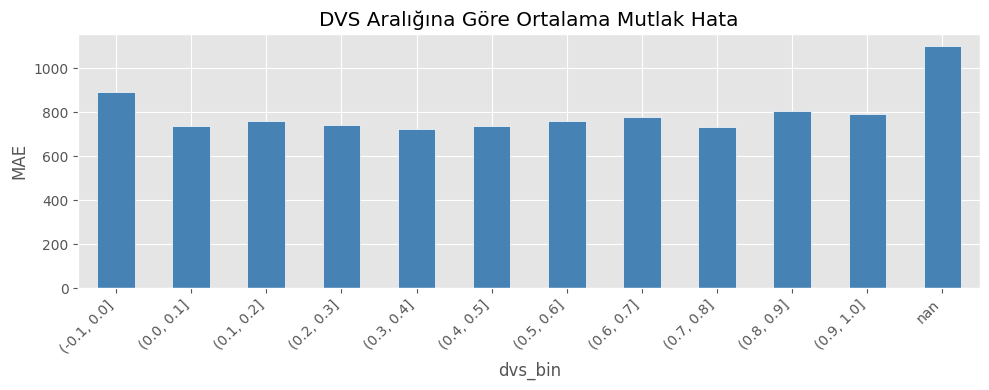

In [22]:
# Hata — DVS bazlı
test_df['dvs_bin'] = pd.cut(test_df['DVS'], bins=np.arange(-0.1, 1.1, 0.1)).astype(str)
dvs_err = test_df.groupby('dvs_bin')['abs_error'].mean().sort_index()

plt.figure(figsize=(10, 4))
dvs_err.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('DVS Aralığına Göre Ortalama Mutlak Hata')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 9. Crop Bazlı Breakdown

In [23]:
crop_metrics = []
for crop, grp in test_df.groupby('crop_name'):
    if len(grp) < 5:
        continue
    crop_metrics.append({
        'crop':       crop,
        'n_rows':     len(grp),
        'RMSE':       round(mean_squared_error(grp[TARGET], grp['y_pred']) ** 0.5, 1),
        'MAE':        round(mean_absolute_error(grp[TARGET], grp['y_pred']), 1),
        'R2':         round(r2_score(grp[TARGET], grp['y_pred']), 3),
        'mean_verim': round(grp[TARGET].mean(), 1)
    })

crop_df = pd.DataFrame(crop_metrics).sort_values('R2', ascending=False)
print(crop_df.to_string(index=False))

       crop  n_rows   RMSE    MAE            R2  mean_verim
    soybean     119  340.8  314.7  8.550000e-01       842.1
  sunflower     239  520.0  430.9  8.490000e-01      1419.5
 seed_onion     178 1997.4 1699.7  8.400000e-01      8783.6
      maize     259 1667.9 1314.9  8.250000e-01      4914.3
  sugarbeet     255 1159.5  912.1  7.370000e-01      3656.4
sweetpotato     265  675.5  536.4  5.950000e-01      1644.1
     potato     278 1287.5 1166.5  4.820000e-01      4161.3
  groundnut     137  370.4  266.5  4.430000e-01       747.1
    cassava     330  726.8  612.5  3.590000e-01       720.0
   chickpea      82  256.5  169.3  0.000000e+00         1.3
   fababean     227 2133.8 1396.7 -5.840000e-01      5797.7
    sorghum     239  192.8  143.9 -1.691000e+00       130.2
   rapeseed     526  842.1  705.7 -4.002000e+00      2169.2
     barley     232 2010.5 1440.3 -7.322000e+00      6046.4
      wheat     506  773.8  687.9 -8.433000e+00      4286.9
     cotton     376 1835.0 1237.3 -2.152

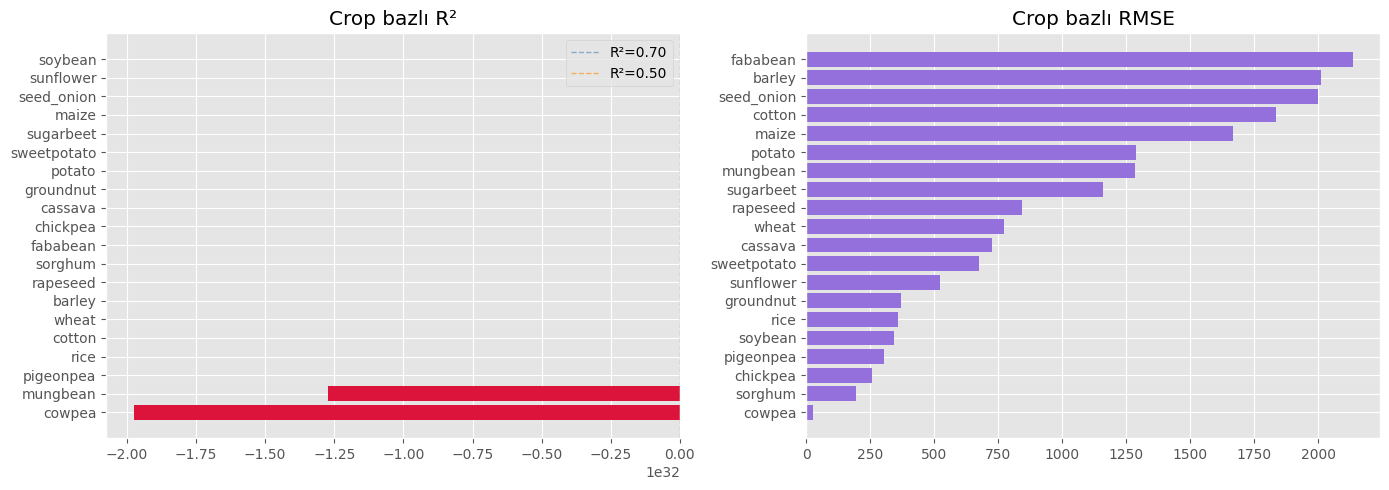

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crop_s = crop_df.sort_values('R2', ascending=True)
colors = ['steelblue' if v >= 0.7 else 'darkorange' if v >= 0.5 else 'crimson' for v in crop_s['R2']]
axes[0].barh(crop_s['crop'], crop_s['R2'], color=colors)
axes[0].axvline(0.7, color='steelblue', ls='--', lw=1, alpha=0.6, label='R²=0.70')
axes[0].axvline(0.5, color='darkorange', ls='--', lw=1, alpha=0.6, label='R²=0.50')
axes[0].set_title('Crop bazlı R²')
axes[0].legend()

crop_r = crop_df.sort_values('RMSE', ascending=True)
axes[1].barh(crop_r['crop'], crop_r['RMSE'], color='mediumpurple')
axes[1].set_title('Crop bazlı RMSE')

plt.tight_layout()
plt.show()

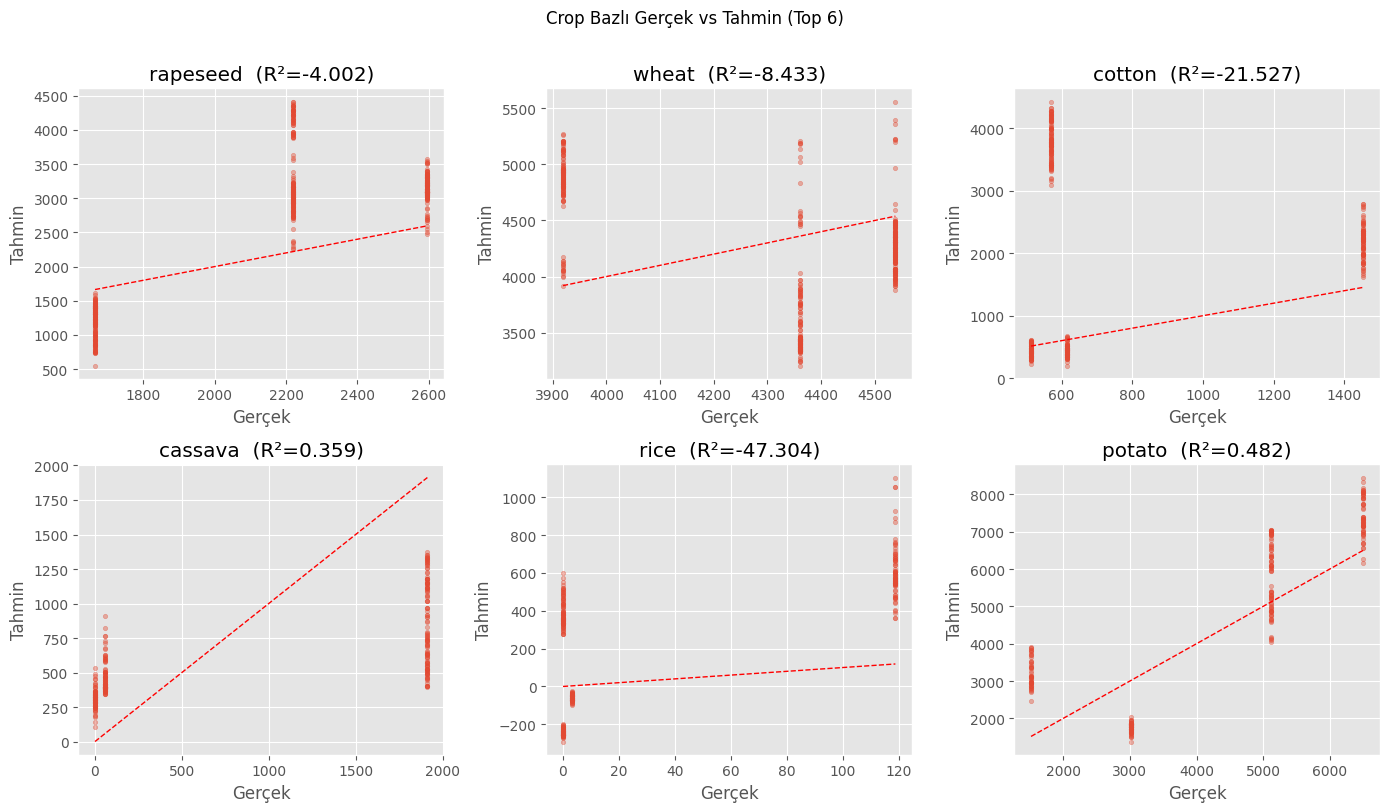

In [25]:
top_crops = crop_df.sort_values('n_rows', ascending=False)['crop'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, crop in zip(axes.flat, top_crops):
    sub = test_df[test_df['crop_name'] == crop]
    ax.scatter(sub[TARGET], sub['y_pred'], alpha=0.4, s=10)
    lims = [sub[TARGET].min(), sub[TARGET].max()]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_title(f'{crop}  (R²={r2_score(sub[TARGET], sub["y_pred"]):.3f})')
    ax.set_xlabel('Gerçek')
    ax.set_ylabel('Tahmin')

plt.suptitle('Crop Bazlı Gerçek vs Tahmin (Top 6)', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Model Kaydetme

In [26]:
model_path   = MODEL_DIR / 'lgbm_yield_final.pkl'
feature_path = MODEL_DIR / 'feature_cols.pkl'
metrics_path = MODEL_DIR / 'metrics.csv'

joblib.dump(final_model, model_path)
joblib.dump(FEATURE_COLS, feature_path)

metrics_df = pd.DataFrame([{
    'model':         'LightGBM',
    'strategy':      'GroupKFold',
    'dvs_filter':    'DVS < 1.0',
    'leaky_removed': str(LEAKY_COLS),
    'RMSE':          round(rmse, 2),
    'MAE':           round(mae, 2),
    'R2':            round(r2, 4),
    'MAPE':          round(mape, 2),
    'n_features':    len(FEATURE_COLS),
    'n_estimators':  final_model.best_iteration_,
}])
metrics_df.to_csv(metrics_path, index=False)

print(f'Model      : {model_path}')
print(f'Features   : {feature_path}')
print(f'Metrikler  : {metrics_path}')
print('\n── Kaydedilen metrikler ──')
print(metrics_df.to_string(index=False))

Model      : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/lgbm_yield_final.pkl
Features   : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/feature_cols.pkl
Metrikler  : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/metrics.csv

── Kaydedilen metrikler ──
   model   strategy dvs_filter                            leaky_removed    RMSE    MAE     R2     MAPE  n_features  n_estimators
LightGBM GroupKFold  DVS < 1.0 ['TWSO', 'TAGP', 'TWLV', 'TWST', 'TWRT'] 1179.39 792.21 0.8207 28976.35          36          1535


In [27]:
print('── Modeli yeniden yükle ve tahmin et ──')
loaded_model = joblib.load(model_path)
loaded_feats = joblib.load(feature_path)

sample = X_test.iloc[:5]
preds  = loaded_model.predict(sample)
print(pd.DataFrame({
    'Gerçek': y_test.values[:5],
    'Tahmin': preds.round(1),
    'Fark':   (y_test.values[:5] - preds).round(1)
}))

── Modeli yeniden yükle ve tahmin et ──
         Gerçek   Tahmin    Fark
0   9865.043288  10098.1  -233.1
1    649.694579   2018.6 -1368.9
2  13073.231512  10120.9  2952.4
3  11944.666723   9231.1  2713.5
4   9865.043288  10230.0  -365.0
